# 2019 Real Holdout Demand Forecasting & Anomaly Analysis Suite

This notebook performs **2019 Real Demand Forecasting & Forecast-Aware Anomaly Detection** across all 8 pharmaceutical drug categories.

### Pipeline Overview:
1. **Loads 2019 Champion Model Forecasts** ($P_{50}$ median anchor, $P_{10}$ lean lower bound, $P_{90}$ upper safety bound).
2. **Runs Stage 2 Forecast-Aware Isolation Forest** on actual 2019 sales data.
3. **Flags Sales Anomalies** (unannounced demand surges, unexpected drop-offs, and supply stockouts).
4. **Exports Detailed Anomaly Reports & Interactive Time-Series Charts**.


In [1]:
import os, sys, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\anomaly_detection'
sum_df = pd.read_csv(os.path.join(OUTPUT_DIR, '2019_anomaly_detection_summary.csv'))

print("==========================================================================")
print("  2019 REAL HOLDOUT ANOMALY DETECTION SUMMARY REPORT")
print("==========================================================================")
display(sum_df)


  2019 REAL HOLDOUT ANOMALY DETECTION SUMMARY REPORT


,Drug Category,Total 2019 Days,Detected Anomalies,Anomaly Rate (%),Avg Anomaly Deviation,Max Anomaly Spike
0,M01AB,281,20,7.12,5.95,12.87
1,M01AE,281,32,11.39,4.20,10.41
2,N02BA,281,12,4.27,3.60,9.61
3,N02BE,281,21,7.47,22.95,46.64
4,N05B,281,6,2.14,9.92,16.15
5,N05C,281,3,1.07,3.15,4.53
6,R03,281,21,7.47,21.31,38.35
7,R06,281,15,5.34,5.97,9.83


In [2]:
# Display Top 15 Highest-Deviation Anomalies across all drugs in 2019
anom_detail_df = pd.read_csv(os.path.join(OUTPUT_DIR, '2019_detected_anomalies_detail.csv'))

top_anom = anom_detail_df[['date', 'drug_category', 'actual_sales', 'Expected Demand Anchor (P50)', 'residual', 'anomaly_type', 'anomaly_score']].sort_values('residual', key=abs, ascending=False).head(15)

print("==========================================================================")
print("  TOP 15 HIGHEST-DEVIATION DETECTED ANOMALIES (2019)")
print("==========================================================================")
display(top_anom)


  TOP 15 HIGHEST-DEVIATION DETECTED ANOMALIES (2019)


,date,drug_category,actual_sales,Expected Demand Anchor (P50),residual,anomaly_type,anomaly_score
64,2019-01-20,N02BE,93.05,46.41,46.64,Demand Surge Spike,0.661442
65,2019-01-26,N02BE,97.80,53.18,44.62,Demand Surge Spike,0.654289
66,2019-01-13,N02BE,73.00,31.78,41.22,Demand Surge Spike,0.647419
67,2019-01-27,N02BE,100.10,59.05,41.05,Demand Surge Spike,0.677375
94,2019-02-02,R03,45.00,6.65,38.35,Demand Surge Spike,0.684374
68,2019-04-22,N02BE,51.00,16.81,34.19,Demand Surge Spike,0.626677
69,2019-01-22,N02BE,74.90,41.52,33.38,Demand Surge Spike,0.609800
70,2019-01-09,N02BE,64.80,31.57,33.23,Demand Surge Spike,0.571674
95,2019-02-28,R03,35.00,3.64,31.36,Demand Surge Spike,0.685021
96,2019-07-30,R03,33.00,2.13,30.87,Demand Surge Spike,0.681186


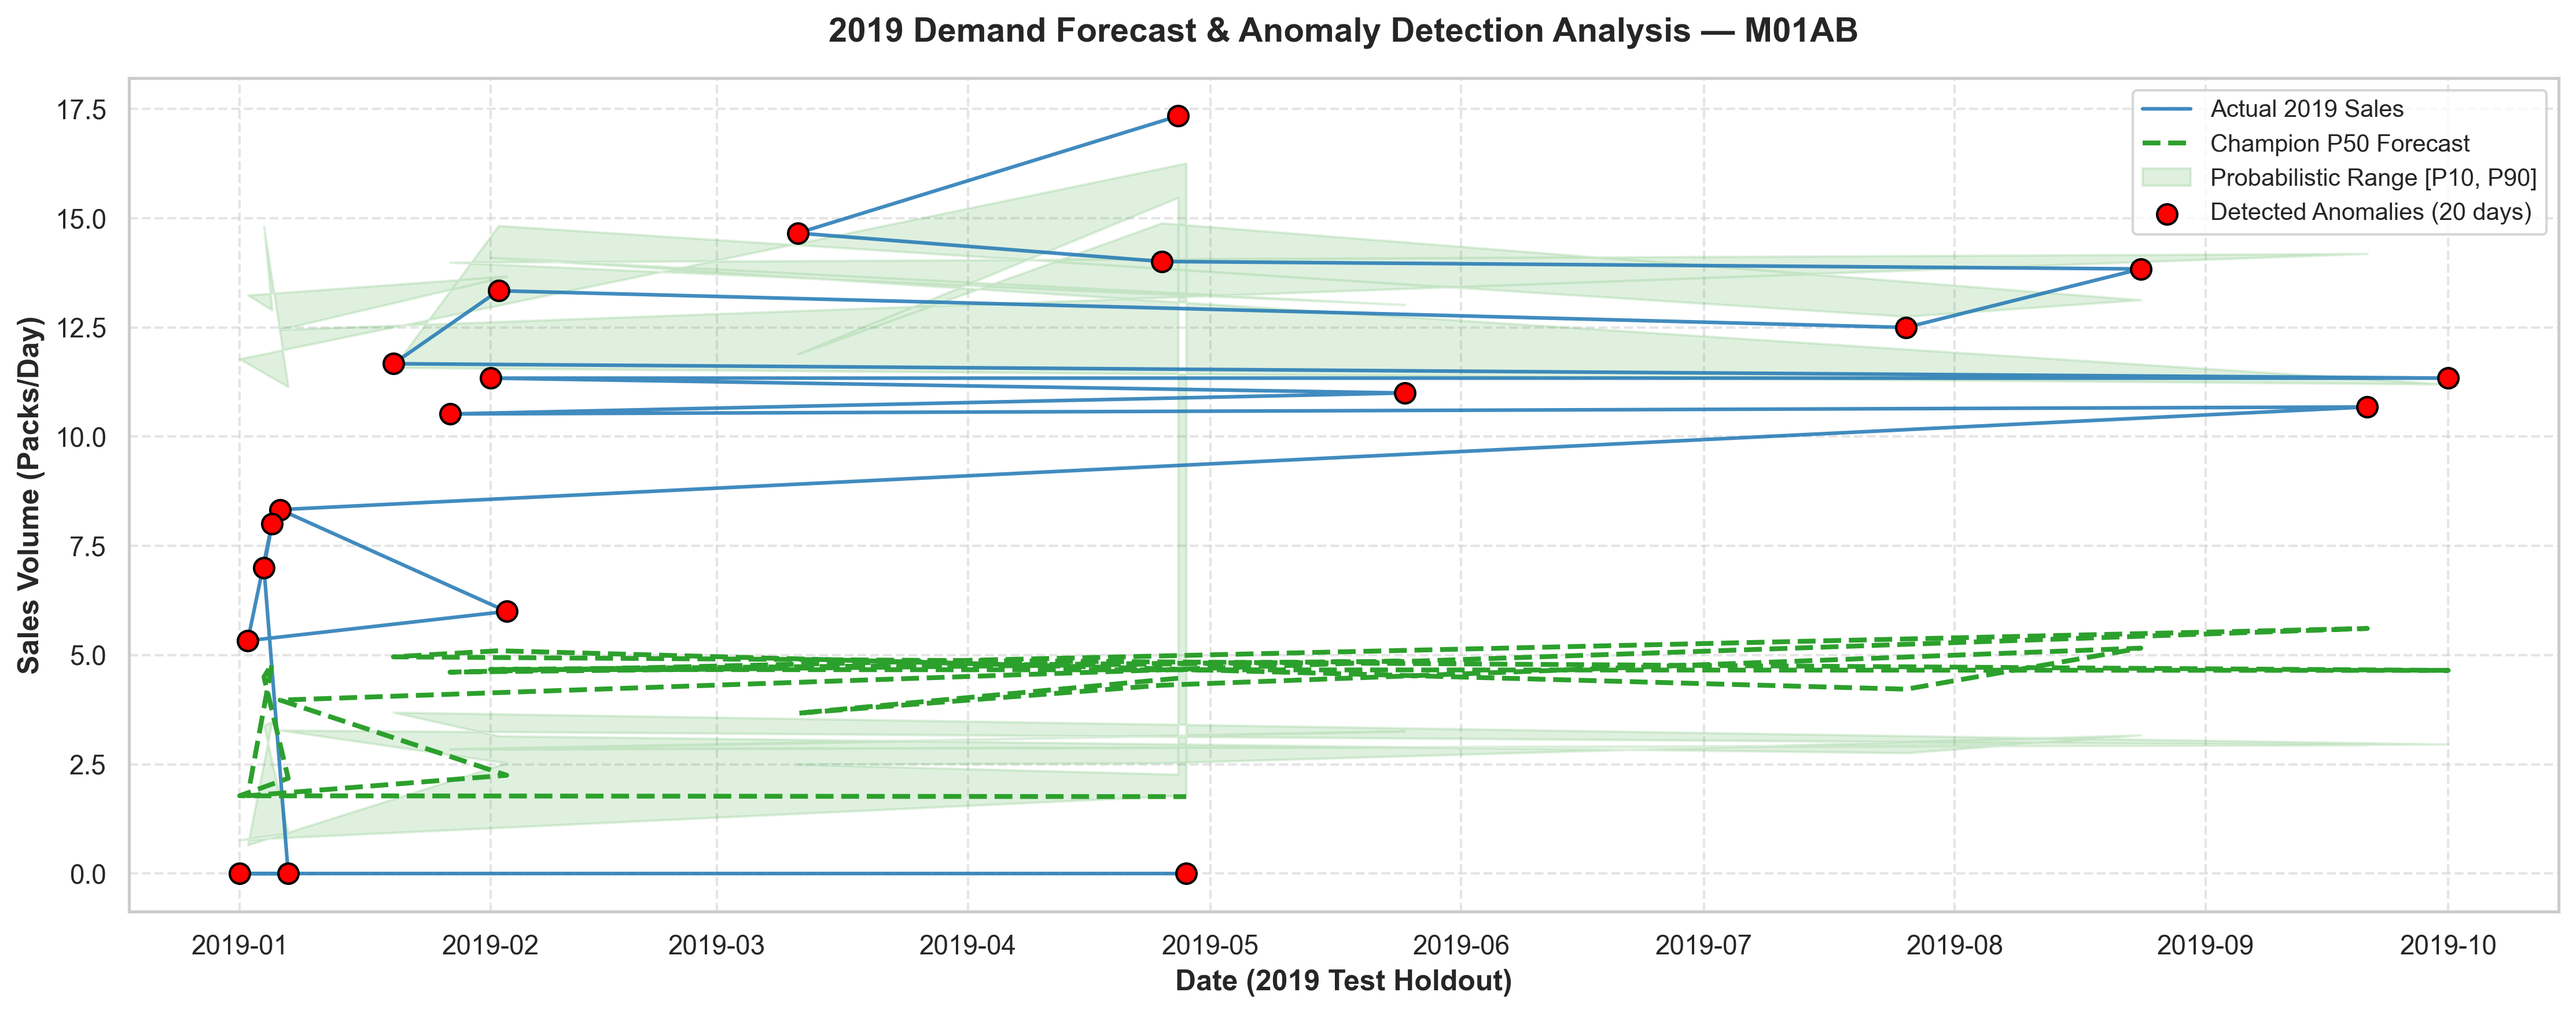

In [3]:
# Visualizing 2019 Forecast + Probabilistic Range + Anomalies for M01AB
df_2019 = pd.read_csv(os.path.join(OUTPUT_DIR, '2019_detected_anomalies_detail.csv'))
m01ab_df = df_2019[df_2019['drug_category'] == 'M01AB'].copy()
m01ab_df['date'] = pd.to_datetime(m01ab_df['date'])

plt.figure(figsize=(15, 6), dpi=300)

plt.plot(m01ab_df['date'], m01ab_df['actual_sales'], label='Actual 2019 Sales', color='#1f77b4', linewidth=1.5, alpha=0.85)
plt.plot(m01ab_df['date'], m01ab_df['Expected Demand Anchor (P50)'], label='Champion P50 Forecast', color='#2ca02c', linewidth=2.0, linestyle='--')
plt.fill_between(m01ab_df['date'], m01ab_df['Lean Lower Bound (P10)'], m01ab_df['Upper Target Stock (P90)'], color='#2ca02c', alpha=0.15, label='Probabilistic Range [P10, P90]')

anom_pts = m01ab_df[m01ab_df['is_anomaly'] == 1]
plt.scatter(anom_pts['date'], anom_pts['actual_sales'], color='red', s=70, zorder=5, label=f'Detected Anomalies ({len(anom_pts)} days)', marker='o', edgecolors='black')

plt.title('2019 Demand Forecast & Anomaly Detection Analysis — M01AB', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date (2019 Test Holdout)', fontsize=12, fontweight='bold')
plt.ylabel('Sales Volume (Packs/Day)', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
